<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/star_solarflare.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Solar Flares**

A major X7.1 solar flare (R3 radio blackout) peaked on 1 October at 22:20 UTC. The eruption took place around complex Beta-Gamma-Delta sunspot https://www.spaceweatherlive.com/en/news.html

https://www.spaceweatherlive.com/de/sonnenaktivitat/top-50-sonneneruptionen/jahr/2024.html

In [ ]:
!pip install sunpy[all] drms beautifulsoup4 astropy -q

**Example with Real data**

In [13]:
import sunpy.map
import sunpy.data.sample
from astropy import units as u
from sunpy import *
from sunpy.net import Fido, attrs as a
from astropy.time import Time
import datetime
from sunpy.timeseries import TimeSeries
from bs4 import BeautifulSoup
import requests
import pandas as pd
import numpy as np

class SolarDataFetcher:
    """Class to fetch solar flare data from various sources"""

    def get_goes_xray_data(self, start_time, end_time):
        """
        Fetch GOES X-ray flux data
        Args:
            start_time (str): Start time in format 'YYYY-MM-DD HH:MM:SS'
            end_time (str): End time in format 'YYYY-MM-DD HH:MM:SS'
        Returns:
            sunpy.timeseries.TimeSeriesMetaData: GOES X-ray data
        """
        try:
            # Convert string times to datetime objects
            start = Time(start_time).datetime
            end = Time(end_time).datetime

            # Search for GOES XRS data
            result = Fido.search(a.Time(start, end),
                               a.Instrument('XRS'),
                               a.goes.SatelliteNumber(16))

            # Download the data
            downloaded_files = Fido.fetch(result)

            # Create TimeSeries from downloaded data
            goes_ts = TimeSeries(downloaded_files)

            return goes_ts

        except Exception as e:
            print(f"Error fetching GOES data: {str(e)}")
            return None

    def get_sdo_aia_data(self, start_time, wavelength=171):
        """
        Fetch SDO/AIA image data
        Args:
            start_time (str): Time in format 'YYYY-MM-DD HH:MM:SS'
            wavelength (int): Wavelength in Angstroms (171, 193, 211, 304, etc.)
        Returns:
            sunpy.map.Map: SDO image data
        """
        try:
            # Convert string time to datetime
            search_time = Time(start_time).datetime

            # Search for AIA data
            result = Fido.search(a.Time(search_time, search_time + datetime.timedelta(minutes=1)),
                               a.Instrument('AIA'),
                               a.Wavelength(wavelength * u.angstrom))

            # Download the data
            downloaded_files = Fido.fetch(result)

            # Create Map from downloaded data
            aia_map = sunpy.map.Map(downloaded_files[0])

            return aia_map

        except Exception as e:
            print(f"Error fetching SDO/AIA data: {str(e)}")
            return None

    def get_noaa_flare_events(self, start_date, end_date):
        """
        Fetch NOAA solar flare event list
        Args:
            start_date (str): Start date in format 'YYYY-MM-DD'
            end_date (str): End date in format 'YYYY-MM-DD'
        Returns:
            pandas.DataFrame: Flare events data
        """
        try:
            # Format the dates for the NOAA URL
            start = datetime.datetime.strptime(start_date, '%Y-%m-%d')
            end = datetime.datetime.strptime(end_date, '%Y-%m-%d')

            base_url = "https://www.ngdc.noaa.gov/stp/space-weather/solar-data/solar-features/solar-flares/x-rays/goes/xrs/"

            events = []
            current_date = start

            while current_date <= end:
                year = current_date.year
                month = str(current_date.month).zfill(2)

                # Construct URL for monthly data
                url = f"{base_url}/{year}/goes-xrs-report_{year}{month}.txt"

                try:
                    # Read data from URL
                    data = pd.read_csv(url, delimiter=r"\s+", skiprows=2)
                    events.append(data)
                except:
                    print(f"No data available for {year}-{month}")

                # Move to next month
                if current_date.month == 12:
                    current_date = datetime.datetime(current_date.year + 1, 1, 1)
                else:
                    current_date = datetime.datetime(current_date.year,
                                                   current_date.month + 1, 1)

            if events:
                return pd.concat(events, ignore_index=True)
            else:
                return None

        except Exception as e:
            print(f"Error fetching NOAA event data: {str(e)}")
            return None

    def get_hek_flare_data(self, start_time, end_time):
        """
        Fetch flare data from the Heliophysics Event Knowledgebase (HEK)
        Args:
            start_time (str): Start time in format 'YYYY-MM-DD HH:MM:SS'
            end_time (str): End time in format 'YYYY-MM-DD HH:MM:SS'
        Returns:
            list: HEK flare events
        """
        try:
            # Convert string times to datetime objects
            start = Time(start_time).datetime
            end = Time(end_time).datetime

            # Search for flare events in HEK
            result = Fido.search(a.Time(start, end),
                               a.hek.EventType('FL'),  # FL for flare
                               a.hek.FL.GOESCls > 'B1.0')  # Only get flares above B1.0

            return result

        except Exception as e:
            print(f"Error fetching HEK data: {str(e)}")
            return None

The main data sources available are:

1. GOES Satellite Data:

X-ray flux measurements
High temporal resolution
Access through SunPy's Fido interface
Most similar to LIGO data in terms of time series format


2. SDO/AIA (Solar Dynamics Observatory):

High-resolution solar images
Multiple wavelengths available
Similar to Kepler/TESS in terms of image data handling


3. NOAA SWPC Data:

Cataloged flare events
Classifications and properties
Historical archive


4. HEK (Heliophysics Event Knowledgebase):

Comprehensive database of solar events
Multiple event types
Cross-referenced with various instruments

In [16]:
# Initialize the fetcher
fetcher = SolarDataFetcher()

# Example: Get GOES X-ray data for a specific time range
goes_data = fetcher.get_goes_xray_data('2024-09-01 00:00:00', '2024-10-02 00:00:00')

# Example: Get SDO/AIA image data
sdo_image = fetcher.get_sdo_aia_data('2024-09-01 12:00:00', wavelength=171)

# Example: Get NOAA flare events
flare_events = fetcher.get_noaa_flare_events('2024-09-01', '2024-10-31')

# Example: Get HEK flare data
hek_events = fetcher.get_hek_flare_data('2024-09-01 00:00:00', '2024-10-02 00:00:00')

Files Downloaded:   0%|          | 0/64 [00:00<?, ?file/s]

sci_xrsf-l2-flx1s_g16_d20240904_v2-2-0.nc:   0%|          | 0.00/5.15M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240902_v2-2-0.nc:   0%|          | 0.00/5.18M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240901_v2-2-0.nc:   0%|          | 0.00/5.20M [00:00<?, ?B/s]

sci_xrsf-l2-flx1s_g16_d20240903_v2-2-0.nc:   0%|          | 0.00/5.14M [00:00<?, ?B/s]

...

aia.lev1.171A_2024_09_01T12_00_57.35Z.image_lev1.fits:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

aia.lev1.171A_2024_09_01T12_00_09.35Z.image_lev1.fits:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

aia.lev1.171A_2024_09_01T12_00_21.35Z.image_lev1.fits:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

aia.lev1.171A_2024_09_01T12_00_45.35Z.image_lev1.fits:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

No data available for 2024-09
No data available for 2024-10


**Analyze with data loaded from NOAA SWPC**

In [11]:
import pandas as pd
import numpy as np
import requests
from datetime import datetime, timedelta
import json

class SolarDataSimpleFetcher:
    """Simple class to fetch solar flare data from NOAA's public APIs"""

    def __init__(self):
        self.noaa_api_base = "https://services.swpc.noaa.gov/json"

    def get_recent_flares(self):
        """
        Fetch recent solar flare data from NOAA SWPC
        Returns:
            pandas.DataFrame: Recent flare events
        """
        try:
            # Get last 30 days of flare events
            url = f"{self.noaa_api_base}/goes/primary"
            response = requests.get(url)

            if response.status_code == 200:
                data = response.json()
                df = pd.DataFrame(data)

                # Convert time columns to datetime
                df['time_tag'] = pd.to_datetime(df['time_tag'])

                # Get relevant columns
                df = df[['time_tag', 'flux', 'observed_flux']]

                return df
            else:
                print(f"Error: HTTP {response.status_code}")
                return None

        except Exception as e:
            print(f"Error fetching recent flare data: {str(e)}")
            return None

    def get_flare_events(self, start_date, end_date):
        """
        Fetch NOAA solar flare event list from text archives
        Args:
            start_date (str): Start date in format 'YYYY-MM-DD'
            end_date (str): End date in format 'YYYY-MM-DD'
        Returns:
            pandas.DataFrame: Flare events data
        """
        try:
            events = []
            current = datetime.strptime(start_date, '%Y-%m-%d')
            end = datetime.strptime(end_date, '%Y-%m-%d')

            while current <= end:
                # Construct URL for daily events
                url = f"https://services.swpc.noaa.gov/text/xray-flares.txt"

                try:
                    # Read data from URL
                    df = pd.read_csv(url, delimiter=r"\s+", skiprows=6)
                    events.append(df)
                except Exception as e:
                    print(f"Error reading data for {current.strftime('%Y-%m-%d')}: {str(e)}")

                current += timedelta(days=1)

            if events:
                combined_df = pd.concat(events, ignore_index=True)
                # Clean up column names
                combined_df.columns = combined_df.columns.str.strip().str.lower()
                return combined_df
            else:
                return None

        except Exception as e:
            print(f"Error fetching event data: {str(e)}")
            return None

    def get_forecast(self):
        """
        Fetch NOAA's solar activity forecast
        Returns:
            dict: Solar activity forecast data
        """
        try:
            url = f"{self.noaa_api_base}/solar-cycle/solar-cycle-prediction.json"
            response = requests.get(url)

            if response.status_code == 200:
                return response.json()
            else:
                print(f"Error: HTTP {response.status_code}")
                return None

        except Exception as e:
            print(f"Error fetching forecast data: {str(e)}")
            return None

    def save_data(self, data, filename):
        """
        Save retrieved data to a file
        Args:
            data: DataFrame or dict to save
            filename (str): Name of file to save to
        """
        if isinstance(data, pd.DataFrame):
            data.to_csv(filename, index=False)
        else:
            with open(filename, 'w') as f:
                json.dump(data, f, indent=4)

In [12]:
# Initialize the fetcher
fetcher = SolarDataSimpleFetcher()

# Get recent flare data
recent_flares = fetcher.get_recent_flares()
if recent_flares is not None:
    print("Recent Flares:")
    print(recent_flares.head())

    # Save to CSV
    fetcher.save_data(recent_flares, 'recent_flares.csv')

# Get flare events for a specific date range
events = fetcher.get_flare_events('2024-01-01', '2024-01-31')
if events is not None:
    print("\nFlare Events:")
    print(events.head())

    # Save to CSV
    fetcher.save_data(events, 'flare_events.csv')

# Get solar activity forecast
forecast = fetcher.get_forecast()
if forecast is not None:
    print("\nSolar Activity Forecast:")
    print(json.dumps(forecast, indent=2))

    # Save to JSON
    fetcher.save_data(forecast, 'forecast.json')

Error fetching recent flare data: Expecting value: line 1 column 1 (char 0)
Error reading data for 2024-01-01: HTTP Error 404: Not Found
Error reading data for 2024-01-02: HTTP Error 404: Not Found
Error reading data for 2024-01-03: HTTP Error 404: Not Found
Error reading data for 2024-01-04: HTTP Error 404: Not Found
Error reading data for 2024-01-05: HTTP Error 404: Not Found
Error reading data for 2024-01-06: HTTP Error 404: Not Found
Error reading data for 2024-01-07: HTTP Error 404: Not Found
Error reading data for 2024-01-08: HTTP Error 404: Not Found
Error reading data for 2024-01-09: HTTP Error 404: Not Found
Error reading data for 2024-01-10: HTTP Error 404: Not Found
Error reading data for 2024-01-11: HTTP Error 404: Not Found
Error reading data for 2024-01-12: HTTP Error 404: Not Found
Error reading data for 2024-01-13: HTTP Error 404: Not Found
Error reading data for 2024-01-14: HTTP Error 404: Not Found
Error reading data for 2024-01-15: HTTP Error 404: Not Found
Error rea

**Analyze synthetic data**

Analyze solar flare data, including classification, duration, and peak intensity calculations.

In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy import signal

class SolarFlareAnalyzer:
    def __init__(self):
        """Initialize the Solar Flare Analyzer"""
        self.flare_classes = {
            'B': 1e-7,
            'C': 1e-6,
            'M': 1e-5,
            'X': 1e-4
        }

    def classify_flare(self, peak_flux):
        """
        Classify solar flare based on peak X-ray flux
        Args:
            peak_flux (float): Peak X-ray flux in W/m²
        Returns:
            str: Flare classification (e.g., 'X1.2')
        """
        for class_letter in ['B', 'C', 'M', 'X']:
            class_flux = self.flare_classes[class_letter]
            if peak_flux < class_flux * 10:
                magnitude = peak_flux / class_flux
                return f"{class_letter}{magnitude:.1f}"
        return f"X{peak_flux / self.flare_classes['X']:.1f}"

    def detect_flare_events(self, time_series, flux_data, threshold_sigma=3):
        """
        Detect solar flare events in time series data
        Args:
            time_series (array): Array of timestamps
            flux_data (array): Array of X-ray flux measurements
            threshold_sigma (float): Number of standard deviations for peak detection
        Returns:
            dict: Dictionary containing detected flare events and their properties
        """
        # Remove background noise using moving average
        background = pd.Series(flux_data).rolling(window=60).mean()
        detrended = flux_data - background

        # Find peaks above threshold
        peaks, properties = signal.find_peaks(
            detrended,
            height=detrended.std() * threshold_sigma,
            distance=20  # Minimum samples between peaks
        )

        flare_events = []
        for peak_idx in peaks:
            # Find start and end of flare
            start_idx = peak_idx
            while start_idx > 0 and detrended[start_idx - 1] > 0:
                start_idx -= 1

            end_idx = peak_idx
            while end_idx < len(detrended) - 1 and detrended[end_idx + 1] > 0:
                end_idx += 1

            # Calculate flare properties
            peak_flux = flux_data[peak_idx]
            duration = (time_series[end_idx] - time_series[start_idx]).total_seconds()
            total_energy = np.trapz(flux_data[start_idx:end_idx+1])

            flare_events.append({
                'start_time': time_series[start_idx],
                'peak_time': time_series[peak_idx],
                'end_time': time_series[end_idx],
                'peak_flux': peak_flux,
                'classification': self.classify_flare(peak_flux),
                'duration': duration,
                'total_energy': total_energy
            })

        return flare_events

    def analyze_flare_properties(self, flare_events):
        """
        Calculate statistical properties of detected flares
        Args:
            flare_events (list): List of detected flare events
        Returns:
            dict: Statistical analysis of flare properties
        """
        if not flare_events:
            return None

        durations = [event['duration'] for event in flare_events]
        peak_fluxes = [event['peak_flux'] for event in flare_events]
        total_energies = [event['total_energy'] for event in flare_events]

        analysis = {
            'total_flares': len(flare_events),
            'duration_stats': {
                'mean': np.mean(durations),
                'median': np.median(durations),
                'std': np.std(durations)
            },
            'peak_flux_stats': {
                'mean': np.mean(peak_fluxes),
                'median': np.median(peak_fluxes),
                'std': np.std(peak_fluxes)
            },
            'energy_stats': {
                'mean': np.mean(total_energies),
                'median': np.median(total_energies),
                'std': np.std(total_energies)
            },
            'class_distribution': {}
        }

        # Calculate class distribution
        for event in flare_events:
            flare_class = event['classification'][0]  # Get main class letter
            analysis['class_distribution'][flare_class] = \
                analysis['class_distribution'].get(flare_class, 0) + 1

        return analysis

    def plot_flare_event(self, time_series, flux_data, flare_event):
        """
        Create visualization of a solar flare event
        Args:
            time_series (array): Array of timestamps
            flux_data (array): Array of X-ray flux measurements
            flare_event (dict): Single flare event dictionary
        """
        start_idx = np.where(time_series == flare_event['start_time'])[0][0]
        end_idx = np.where(time_series == flare_event['end_time'])[0][0]

        plt.figure(figsize=(12, 6))
        plt.semilogy(time_series[start_idx:end_idx+1],
                    flux_data[start_idx:end_idx+1])
        plt.axvline(flare_event['peak_time'], color='r', linestyle='--',
                   label='Peak')
        plt.grid(True)
        plt.xlabel('Time (UTC)')
        plt.ylabel('X-ray Flux (W/m²)')
        plt.title(f'Solar Flare Event - Class {flare_event["classification"]}')
        plt.legend()
        plt.tight_layout()

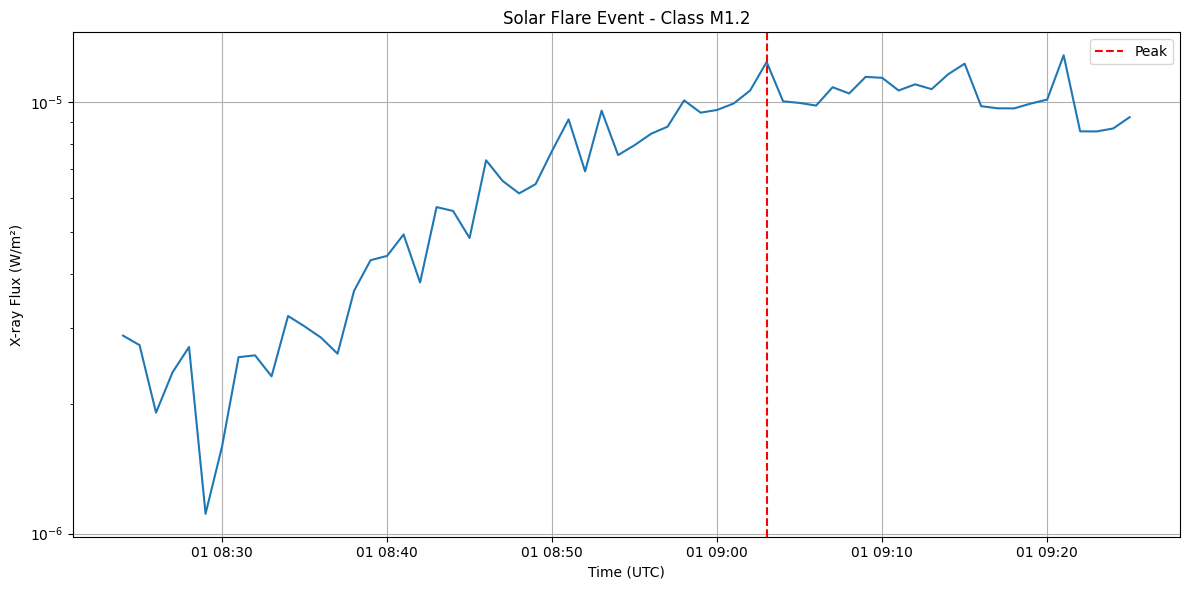

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from scipy import signal

# First define the gaussian pulse function
def gaussian_pulse(length, amp, std):
    """Create a Gaussian pulse"""
    x = np.linspace(-length/2, length/2, length)
    return amp * np.exp(-x**2 / (2*std**2))

# Create sample data
analyzer = SolarFlareAnalyzer()

# Generate synthetic data
times = pd.date_range(start='2024-01-01', periods=1000, freq='1min')
flux = np.random.exponential(1e-6, 1000) + np.random.normal(0, 1e-7, 1000)

# Add synthetic flare
synthetic_flare = gaussian_pulse(100, 1e-5, 20)
flux[500:600] += synthetic_flare

# Detect and analyze flares
flare_events = analyzer.detect_flare_events(times, flux)
analysis_results = analyzer.analyze_flare_properties(flare_events)

# Plot a specific flare
if flare_events:
    analyzer.plot_flare_event(times, flux, flare_events[0])